In [1]:
import numpy as np 
import healpy as hp
import pandas as pd
import matplotlib.pyplot as plt
import tifffile as tiff
import glob
# import seaborn as sns
# sns.set_style("darkgrid")
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from num2words import num2words
from scipy.optimize import curve_fit
from mpl_toolkits import mplot3d
# sns.set(rc={"xtick.bottom": True, "ytick.left": True})
# %matplotlib inline

In [24]:
nside=128

In [25]:
df=pd.read_csv('./database/USA.csv')
Lon=df['Longitude in degrees'].to_numpy()
Lat=df['Latitude in degrees'].to_numpy()
power=df['EIRP'].to_numpy()

In [26]:
pixels=hp.ang2pix(nside,Lon,Lat,lonlat=True)

In [27]:
##---------Read the tif file---------##
image = tiff.imread('./gpw_v4_population_density_adjusted_to_2015_unwpp_country_totals_rev11_2020_15_min.tif')
image_array = np.array(image)


#----------Define the spherical coordinates----------#
theta = np.linspace(np.radians(0), np.radians(180), num=image_array.shape[0],endpoint=False)
phi = np.linspace(-np.radians(180), np.radians(180), num=image_array.shape[1],endpoint=False)



##--------Make empty healpix mask and pixel values vector--------##
healpix_map = np.zeros(hp.nside2npix(nside), dtype=np.double)
pixel_counts = np.zeros(hp.nside2npix(nside), dtype=int)


for i in range(len(theta)):
    for j in range(len(phi)):
        pixel = hp.ang2pix(nside, theta[i], phi[j])
        healpix_map[pixel] += image_array[i, j]
        pixel_counts[pixel] += 1

#--------Average value of each pixel--------#
healpix_map[pixel_counts>0] /= pixel_counts[pixel_counts>0 ]




In [28]:
healpix_map[healpix_map<0]=0

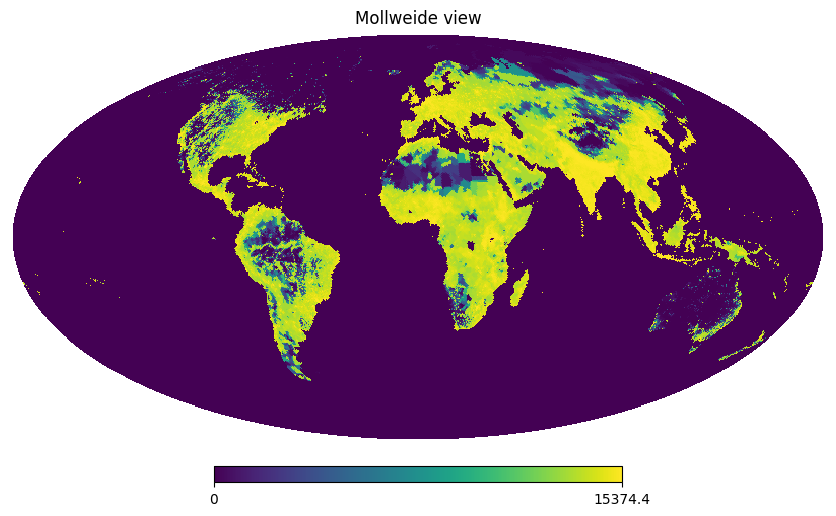

In [29]:
hp.mollview(healpix_map,flip='geo',norm='hist')

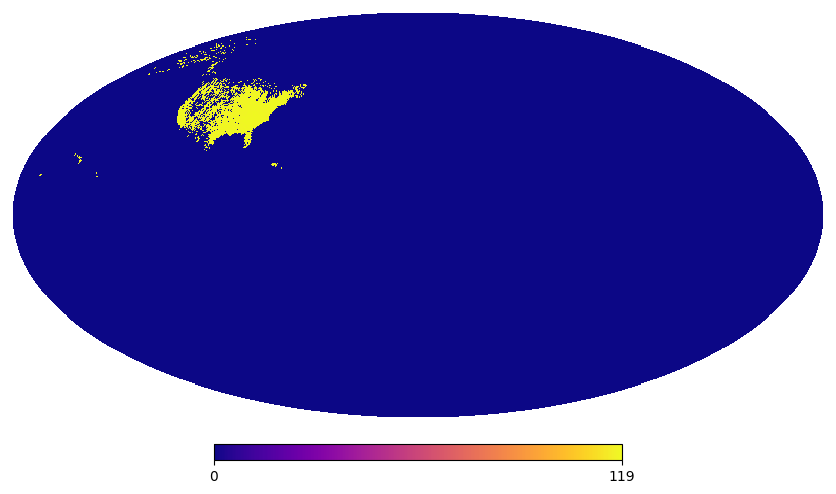

In [30]:
Tx_num_128=np.zeros(hp.nside2npix(nside))
for pix in pixels:
    Tx_num_128[pix]+=1
hp.mollview(Tx_num_128,flip='geo',min=0,cmap='plasma',norm='hist',title='')
# plt.savefig('/home/pratush/Yogen_STARFIRE/STARFIRE_paper_images/new_Txnum.pdf',dpi=600)
plt.show()

In [31]:
valpix=np.where(Tx_num_128>0)

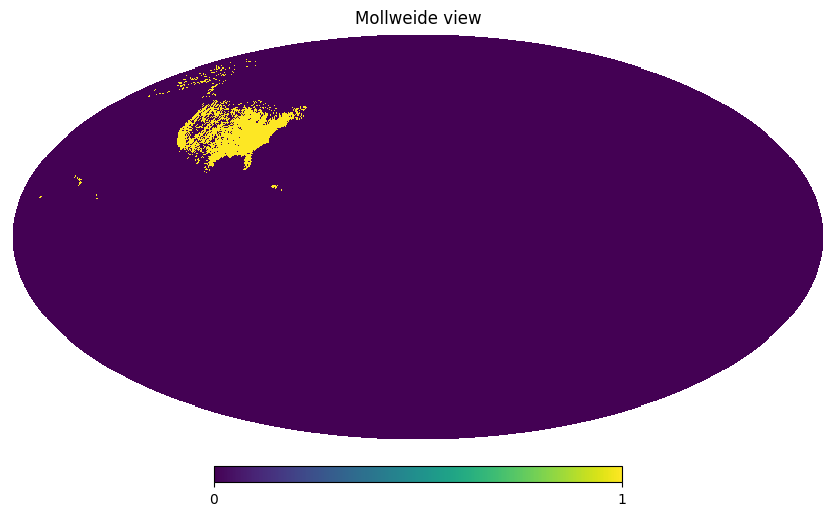

In [32]:
newmap=np.zeros(hp.nside2npix(nside))
for i in valpix:
    newmap[i]+=1
hp.mollview(newmap,flip='geo')

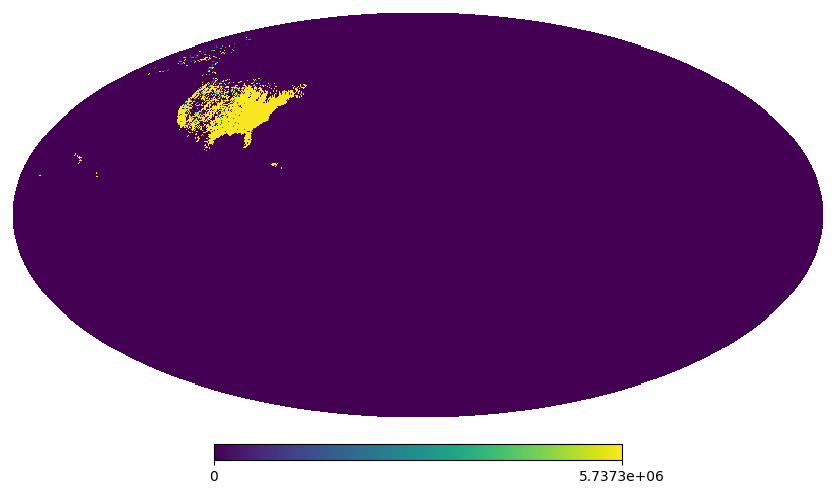

In [33]:
Tx_pow_128=np.zeros(hp.nside2npix(nside))
for index,p in enumerate(pixels):
    Tx_pow_128[p]+=(power[index])
hp.mollview(Tx_pow_128,flip='geo',cmap='viridis',title='',norm='hist')
# plt.savefig('/home/pratush/Yogen_STARFIRE/STARFIRE_paper_images/new_Txpow.pdf',dpi=600)


plt.show()

In [34]:
np.shape(valpix)


(1, 2905)

In [35]:
np.shape(healpix_map)

(196608,)

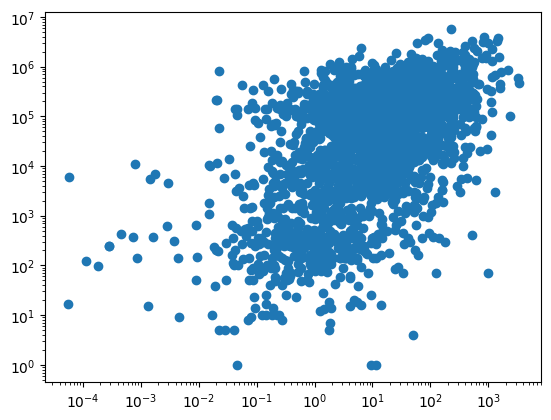

In [40]:
plt.scatter(healpix_map[valpix],Tx_pow_128[valpix])
plt.xscale('log')
plt.yscale('log')
# plt.ylim(bottom=1e5)

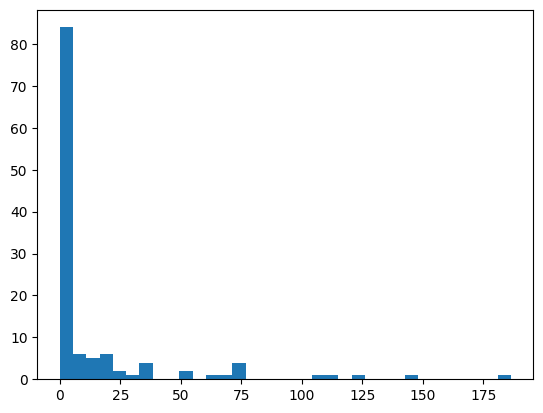

In [32]:
from src2.FDrule import FDrule
plt.hist(healpix_map[valpix],bins=FDrule(healpix_map[valpix]))
plt.show()

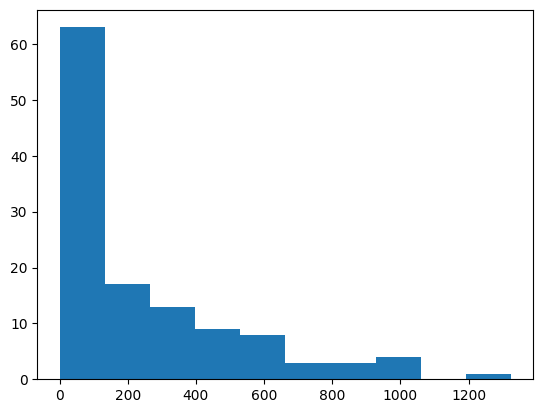

In [33]:
plt.hist(Tx_num_128[valpix],bins=FDrule(Tx_num_128[valpix]))
plt.show()